In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import os



# Pre-processamento e organização de pastas

In [3]:
CAMINHO = "C:\\Users\\Nitro\\Desktop\\Deep_Learning\\Classificacao_Animais\\Dataset"
pasta_dataset =  "animais_dataset"
caminho_atual = os.getcwd()

# Capturando e formando caminho de dataset
caminho_dataset = os.path.join(caminho_atual, pasta_dataset)
print(caminho_dataset)



C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset


In [4]:
# Capturando classes
classes = os.listdir(CAMINHO)

# Construindo variáves de caminhos (test, val e treino)
caminho_treino = os.path.join(caminho_dataset, "treino")
caminho_val = os.path.join(caminho_dataset, "val")
caminho_test = os.path.join(caminho_dataset, "test")



In [5]:
# Construindo função caminhos (test, val e treino)
def consturir_caminho(caminho_treino: str, caminho_val: str, caminho_test:str) -> None:
    os.makedirs(caminho_treino, exist_ok=True)
    os.makedirs(caminho_val, exist_ok=True)
    os.makedirs(caminho_test, exist_ok=True)
    print("Pastas criadas com sucesso!")


In [5]:
#consturir_caminho(caminho_treino= caminho_treino, caminho_val = caminho_val, caminho_test = caminho_test)

In [6]:
for classe in classes:
    classe_atual_treino = os.path.join(caminho_treino, classe)
    classe_atual_val = os.path.join(caminho_val, classe)
    classe_atual_test = os.path.join(caminho_test, classe)

    # Criando pastas de classes
    os.makedirs(classe_atual_treino, exist_ok=True)
    os.makedirs(classe_atual_val, exist_ok=True)
    os.makedirs(classe_atual_test, exist_ok=True)
    print(f"Pasta da classe {classe} criada com sucesso!")




Pasta da classe aranha criada com sucesso!
Pasta da classe borboleta criada com sucesso!
Pasta da classe bovino criada com sucesso!
Pasta da classe cachorros criada com sucesso!
Pasta da classe carneiro criada com sucesso!
Pasta da classe cavalo criada com sucesso!
Pasta da classe elefante criada com sucesso!
Pasta da classe esquilo criada com sucesso!
Pasta da classe galinha criada com sucesso!
Pasta da classe gatos criada com sucesso!
Pasta da classe passaros criada com sucesso!
Pasta da classe peixes criada com sucesso!


In [7]:
# Criando função que move fotos
def copy_image(caminho_origem: str, percents: dict, classe: str, caminho_destino_treino: str, caminho_destino_val: str, caminho_destino_test: str) -> None:
    import random
    import shutil

    caminho_origem_classe = os.path.join(caminho_origem, classe)
    caminho_imagens_origem = [os.path.join(caminho_origem_classe, x) for x in os.listdir(caminho_origem_classe)]

    imagens_treino = random.sample(caminho_imagens_origem, int(len(caminho_imagens_origem) * percents["treino"]))
    sobra_treino = [x for x in caminho_imagens_origem if x not in imagens_treino]
    imagens_teste = random.sample(sobra_treino, int(len(caminho_imagens_origem) * percents["teste"] ))
    imagens_val = [x for x in caminho_imagens_origem if x not in imagens_treino and x not in imagens_teste]
    print(len(imagens_val))
    print(len(imagens_teste))
    print(len(imagens_treino))

    # Copiando imagens
    for x in imagens_treino:
        shutil.copy2(x, caminho_destino_treino)

    for x in imagens_val:
        shutil.copy2(x, caminho_destino_val)

    for x in imagens_teste:
        shutil.copy2(x, caminho_destino_test)




#copy_image("C:\\Users\\Nitro\\Desktop\\Deep_Learning\\Classificacao_Animais\\Dataset\\", {"treino" : 0.7, "val" : 0.1, "teste" : 0.2}, "aranha", "")




In [8]:
# Escolhendo % de treino, val e testes
percent_treino = 0.7
percent_val = 0.1
percent_teste = 0.2
dicts_percent = {"treino" : percent_treino, "val" : percent_val, "teste" : percent_teste}

# Copiando imagens para a pasta raiz
for classe in classes:

    caminho_destino_treino = os.path.join(caminho_treino, classe)
    caminho_destino_val = os.path.join(caminho_val, classe)
    caminho_destino_teste = os.path.join(caminho_test, classe)

    print(caminho_destino_val)
    #copy_image(CAMINHO, dicts_percent, classe, caminho_destino_treino, caminho_destino_val, caminho_destino_teste)



C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\aranha
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\borboleta
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\bovino
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\cachorros
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\carneiro
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\cavalo
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\elefante
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\esquilo
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\galinha
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\gatos
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\val\passaros
C:\Users\Nitro\PyCharmMiscProject\Projetos_DeepLearning\animais_dataset\va

# Separar em treino, teste e validation

In [9]:
current_dir = os.path.abspath(os.getcwd())
#print(current_dir)
folder = "\\animais_dataset"
train_folder = current_dir + folder + "\\treino"
val_folder = current_dir + folder + "\\val"
test_folder = current_dir + folder + "\\test"


# Carregar as imagens para a Rede Neural

In [10]:
import tensorflow as tf
print(tf.__version__)


2.21.0


In [32]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(train_folder, image_size=(180, 180), batch_size=32)
val_dataset = image_dataset_from_directory(val_folder, image_size=(180, 180), batch_size=32)
test_dataset = image_dataset_from_directory(test_folder, image_size=(180, 180), batch_size=32)

Found 2520 files belonging to 12 classes.
Found 360 files belonging to 12 classes.
Found 720 files belonging to 12 classes.


In [33]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    print(data_batch[0].shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32,)
(180, 180, 3)


# Treinando o Modelo

In [43]:
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(input_shape=(180, 180, 3),
                         include_top=False,
                         weights = 'imagenet')

base_model.trainable = False

model = keras.Sequential([
    Rescaling(1./255),
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.2),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')
])

'''model = keras.Sequential(
    [
        Rescaling(scale=1.0/255),
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.2)
    ]
)

model.add(Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(180, 180, 3), padding="same"))
#model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))


model.add(Conv2D(64, kernel_size=(3,3), activation='relu', input_shape=(180, 180, 3), padding="same"))
#model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
#model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'))
#model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(512, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(12, activation='softmax'))
'''
'''model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5)) # Desativa neurônios
model.add(Dense(1, activation="sigmoid"))'''

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


C:\Users\Nitro\AppData\Local\Temp\ipykernel_89460\3262979278.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(180, 180, 3),


In [52]:
#model.fit(train_dataset.take(1), epochs=20)

# Resultados

In [53]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_6 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_6               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_6 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,754,534 (10.51 MB)

 Trainable params: 165,516 (646.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 331,034 (1.26 MB)

In [54]:
'''# pegra 1 batch
for imagens, labels in train_dataset.take(1):
    loss, acc = model.evaluate(imagens, labels, verbose=0)
    print(f"Acurácia no batch: {acc:.4f}")
    break

# avalia no mesmo batch'''

'# pegra 1 batch\nfor imagens, labels in train_dataset.take(1):\n    loss, acc = model.evaluate(imagens, labels, verbose=0)\n    print(f"Acurácia no batch: {acc:.4f}")\n    break\n\n# avalia no mesmo batch'

In [55]:
num_epochs = 100

In [56]:
callbacks_list = [
    keras.callbacks.ModelCheckpoint(
        filepath = 'modelh5.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1)
]

In [57]:
history = model.fit(train_dataset,
                    validation_data=val_dataset,
                    epochs=num_epochs,
                    callbacks=callbacks_list,
                    )

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7895 - loss: 0.6808
Epoch 1: val_loss improved from None to 0.21184, saving model to modelh5.keras

Epoch 1: finished saving model to modelh5.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 340ms/step - accuracy: 0.8040 - loss: 0.6455 - val_accuracy: 0.9361 - val_loss: 0.2118
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.8686 - loss: 0.4183
Epoch 2: val_loss improved from 0.21184 to 0.17548, saving model to modelh5.keras

Epoch 2: finished saving model to modelh5.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 325ms/step - accuracy: 0.8587 - loss: 0.4458 - val_accuracy: 0.9333 - val_loss: 0.1755
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8852 - loss: 0.3707
Epoch 3: val_loss did not improve from 0.17548
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 314ms/step - accuracy: 0.8865 - loss: 0.3713 - val_accuracy: 0.9389 - val_loss: 0.1766
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9053 - loss:

# Indicadores

[0.8039682507514954, 0.858730137348175, 0.8865079283714294, 0.8964285850524902, 0.9027777910232544, 0.9075396656990051, 0.9166666865348816, 0.9222221970558167, 0.928174614906311, 0.9289682507514954, 0.9257936477661133, 0.9357143044471741, 0.9384920597076416, 0.9309523701667786, 0.934920608997345, 0.9428571462631226, 0.938095211982727, 0.9444444179534912, 0.9392856955528259, 0.9460317492485046, 0.9464285969734192, 0.9448412656784058, 0.9476190209388733, 0.9476190209388733, 0.9464285969734192, 0.9507936239242554, 0.9480158686637878, 0.9448412656784058, 0.9496031999588013, 0.9515873193740845, 0.949999988079071]


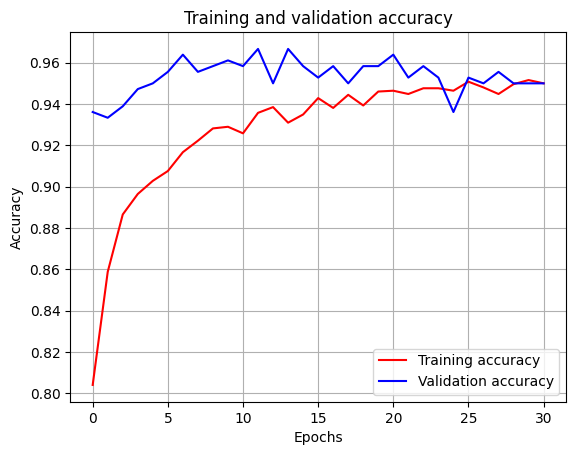

In [58]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
print(acc)

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label="Training accuracy")
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Training and validation accuracy")
plt.legend(loc=4)
plt.grid(axis='both')

plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

In [99]:
loss, acc = model.evaluate(test_dataset)
print(f"Acurácia np teste: {acc:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 245ms/step - accuracy: 0.9556 - loss: 0.1576
Acurácia np teste: 0.9556


In [22]:
# Vendo alguns reports
# Usando sklearn

# Classifivando toda base de teste
'''y_pred = model.predict(x_val)
# voltando para o formato de classes
import numpy as np
y_test_c = np.argmax(y_val, axis=1)

print("Confision Matrix")
print(confusion_matrix(y_test_c, y_pred))
print("Classification Report")
target_names = [str(s) for s in range(9)]
print(classification_report(y_test_c, y_pred, target_names=target_names))'''

'y_pred = model.predict(x_val)\n# voltando para o formato de classes\nimport numpy as np\ny_test_c = np.argmax(y_val, axis=1)\n\nprint("Confision Matrix")\nprint(confusion_matrix(y_test_c, y_pred))\nprint("Classification Report")\ntarget_names = [str(s) for s in range(9)]\nprint(classification_report(y_test_c, y_pred, target_names=target_names))'

# Importando .Keras para minhas fotos

In [106]:
import tensorflow as tf

model_k = tf.keras.models.load_model("modelh5.keras")

In [115]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "C:\\Users\\Nitro\\PyCharmMiscProject\\Projetos_DeepLearning\\animais_dataset\\test\\esquilo\\OIP-28mv_Jx3rXqoXpEud5xW2AHaFj.jpeg"

img = image.load_img(img_path, target_size=(180, 180))
img_array = image.img_to_array(img)

# normalização (igual ao modelo com Rescaling)
#img_array = img_array / 255.0

# adicionar dimensão de batch
img_array = np.expand_dims(img_array, axis = 0)

In [116]:
pred = model_k.predict(img_array)
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[1.0352149e-07 4.5185192e-08 3.8057440e-08 3.2090739e-09 2.0337602e-08
  1.7122916e-07 2.8298290e-08 9.9999809e-01 1.4148451e-06 1.8026984e-08
  1.4864103e-08 2.2460086e-11]]


In [113]:
import os

class_names = os.listdir("C:\\Users\\Nitro\\PyCharmMiscProject\\Projetos_DeepLearning\\animais_dataset\\treino")
print(class_names)

['aranha', 'borboleta', 'bovino', 'cachorros', 'carneiro', 'cavalo', 'elefante', 'esquilo', 'galinha', 'gatos', 'passaros', 'peixes']


In [117]:
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred)

print(f"Classe: {pred_class}")
print(f"Confidence: {confidence:.2%}")

Classe: esquilo
Confidence: 100.00%
